# 01 · Exploratory data analysis

Visualises the M5 sales hierarchy (network → state → store → category → 
department → item × store), calendar effects (weekly cycle, holidays, 
SNAP), and price distributions.

**Prereqs:** `make prep` so `data/processed/long.parquet` exists.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from m5.config import SETTINGS
from m5.data import load_calendar, load_prices
from m5.plots import configure_style, format_yaxis_thousands

configure_style(figsize=(14, 4))

## Load processed data

In [3]:
df = pd.read_parquet(SETTINGS.processed_dir / 'long.parquet')
cal = load_calendar(SETTINGS.raw_dir)
prices = load_prices(SETTINGS.raw_dir)

print(
    f'long: {len(df):,d} rows, {df.unique_id.nunique():,d} series, ' 
    f'{df.ds.nunique():,d} days ({df.ds.min().date()} -> {df.ds.max().date()})'
)
df.head()

long: 1,004,671 rows, 5,000 series, 201 days (2015-11-04 -> 2016-05-22)


,unique_id,item_id,dept_id,cat_id,store_id,state_id,d,y,ds,wm_yr_wk,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1741,0.0,2015-11-04,11540,none,none,none,none,1,0,0,2.24
1,FOODS_1_001_CA_1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1742,0.0,2015-11-05,11540,none,none,none,none,1,1,1,2.24
2,FOODS_1_001_CA_1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1743,0.0,2015-11-06,11540,none,none,none,none,1,1,1,2.24
3,FOODS_1_001_CA_1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1744,1.0,2015-11-07,11541,none,none,none,none,1,1,0,2.24
4,FOODS_1_001_CA_1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1745,0.0,2015-11-08,11541,none,none,none,none,1,0,1,2.24


## Sales hierarchy

Five aggregations of the same series — the higher we go in the hierarchy 
the more dominant the weekly seasonality and the rarer the outliers (Christmas 
is the standout — Walmart is closed).

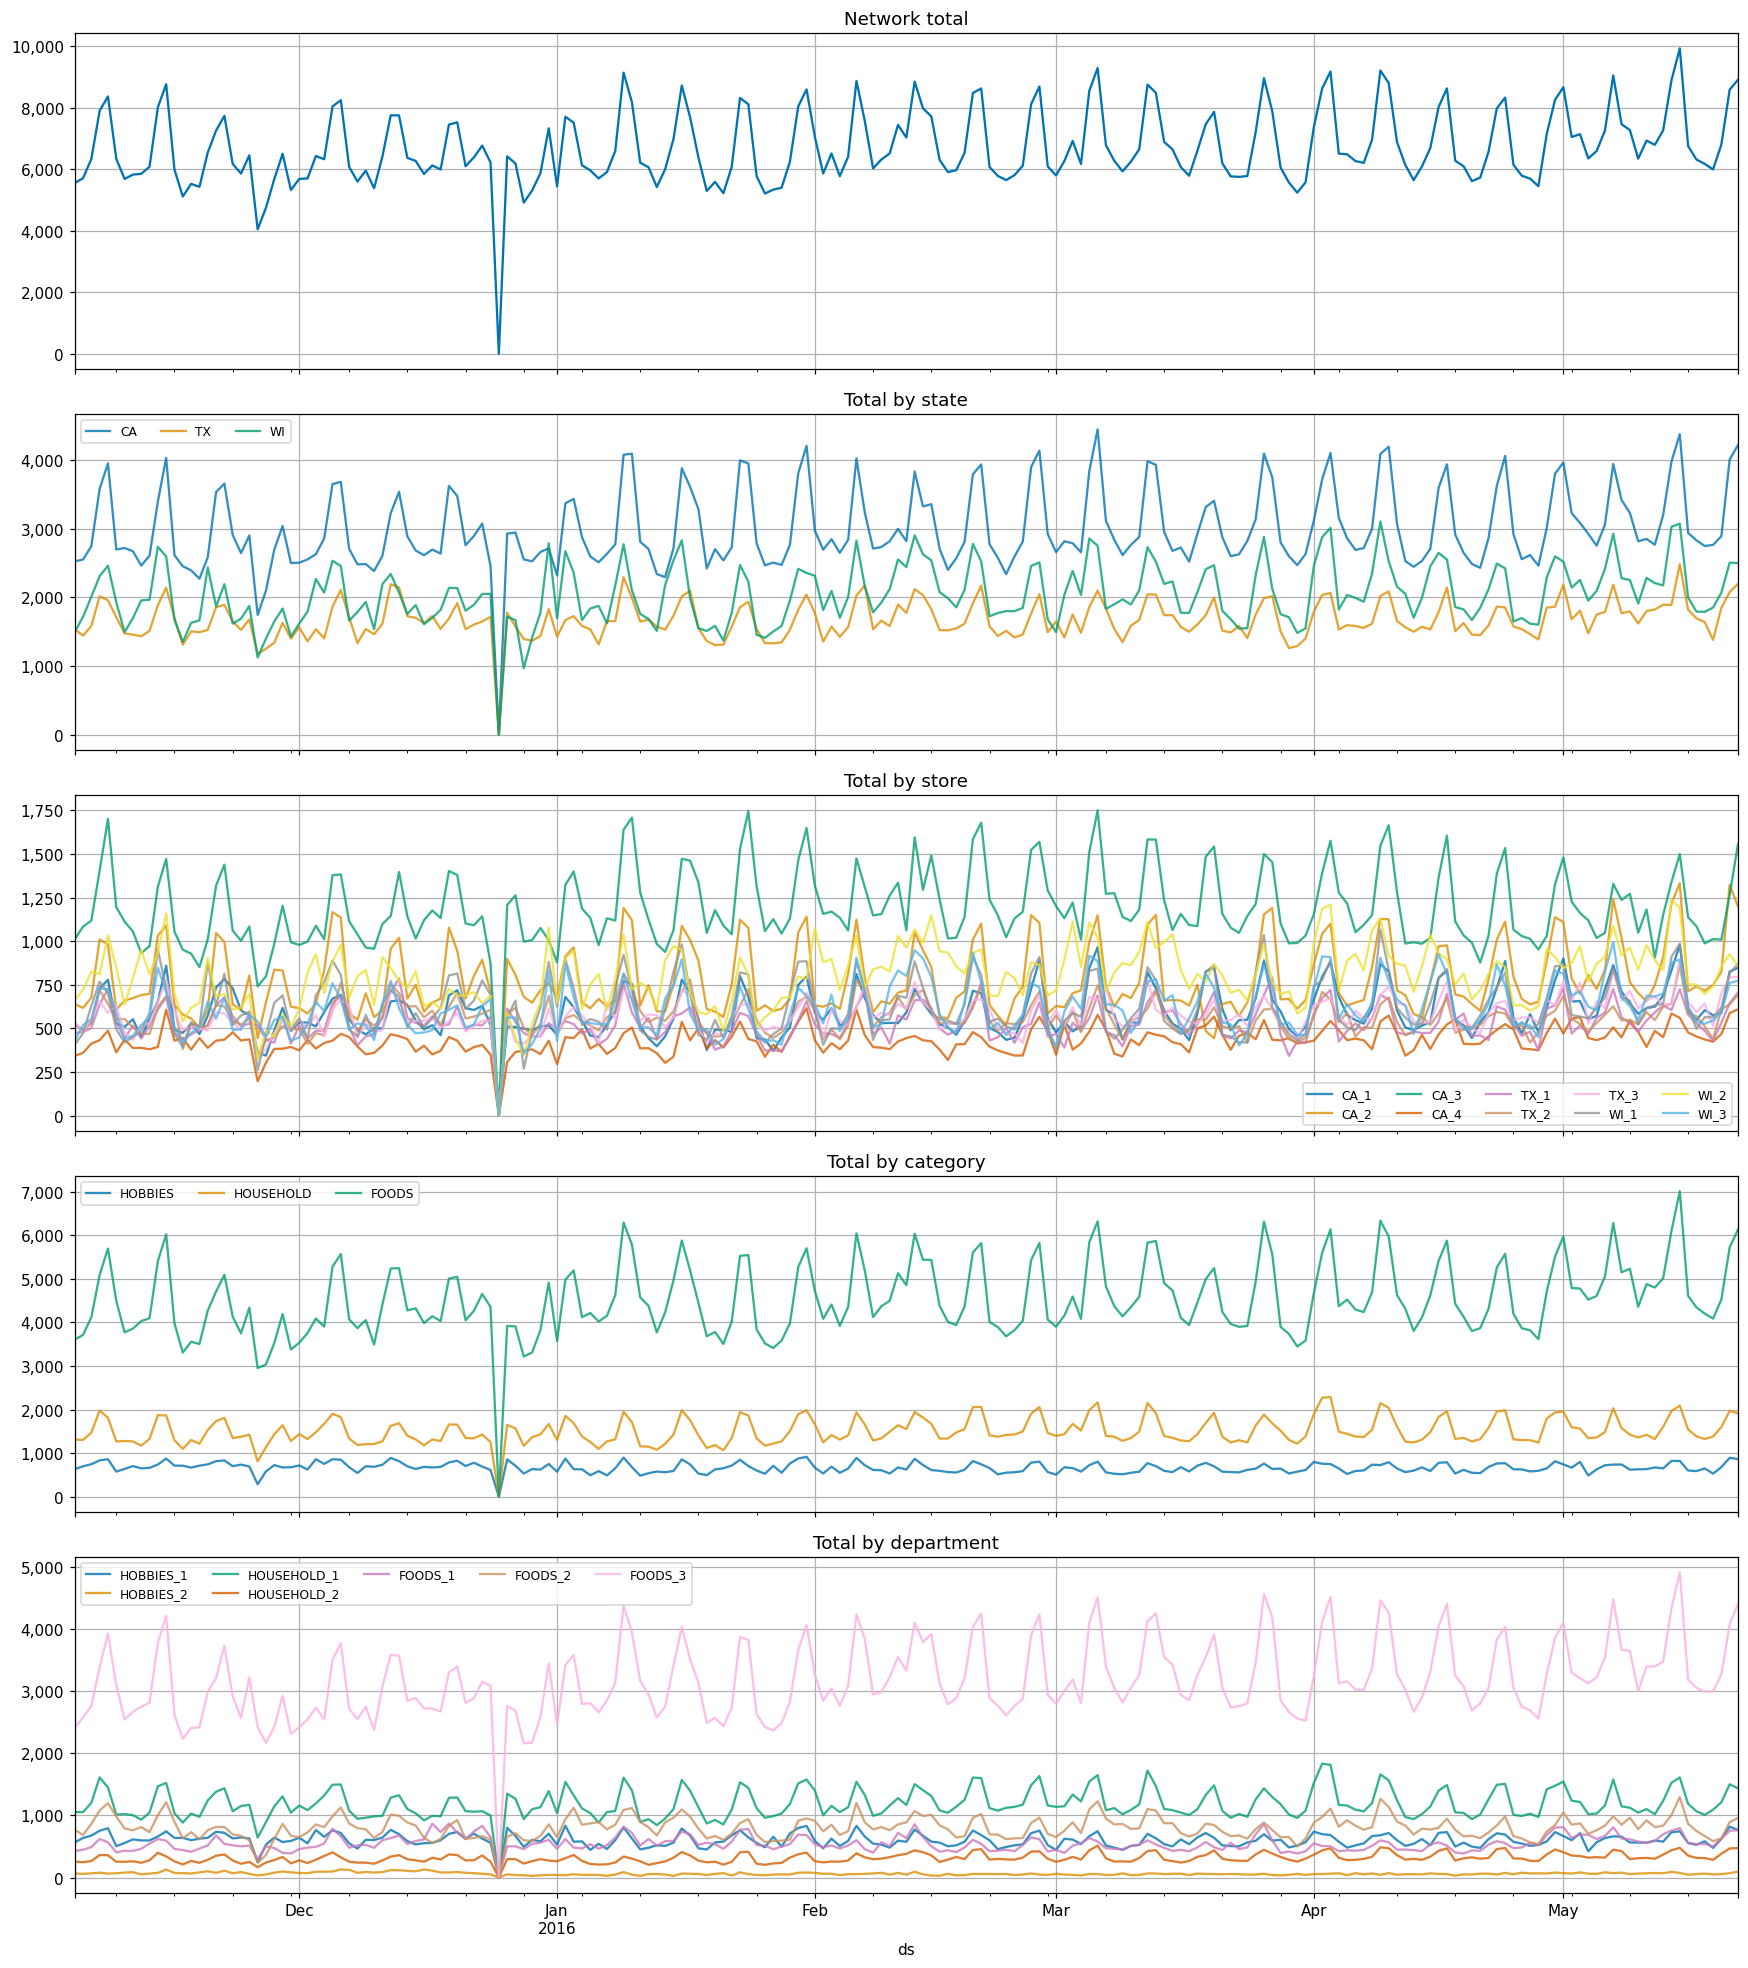

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)
levels = [
    ('Network total',    None),
    ('Total by state',   'state_id'),
    ('Total by store',   'store_id'),
    ('Total by category','cat_id'),
    ('Total by department','dept_id'),
]
for ax, (title, group) in zip(axes, levels):
    if group is None:
        df.groupby('ds', observed=True)['y'].sum().plot(ax=ax)
    else:
        for key, sub in df.groupby(group, observed=True):
            sub.groupby('ds', observed=True)['y'].sum().plot(ax=ax, label=str(key), alpha=0.8)
        ax.legend(ncol=5, fontsize=8)
    ax.set_title(title)
    format_yaxis_thousands(ax)
fig.tight_layout()

## Price distributions by category

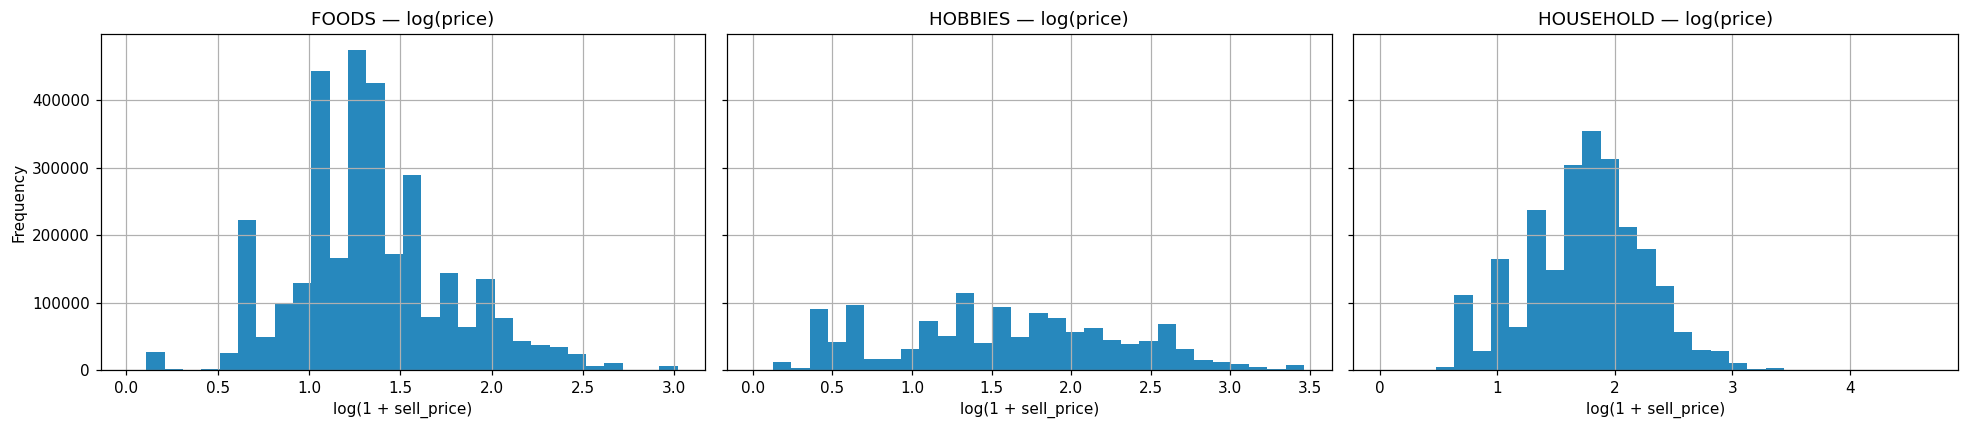

In [5]:
prices_with_cat = prices.assign(category=prices['item_id'].astype(str).str.split('_').str[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, (cat, sub) in zip(axes, prices_with_cat.groupby('category', observed=True)):
    np.log1p(sub['sell_price']).plot.hist(bins=30, ax=ax, alpha=0.85)
    ax.set_title(f'{cat} — log(price)')
    ax.set_xlabel('log(1 + sell_price)')
fig.tight_layout()

## Calendar effects

Day-of-week dominates daily seasonality. Christmas is the lone hard outlier; 
the rest of December trades within the typical week-of-year envelope.

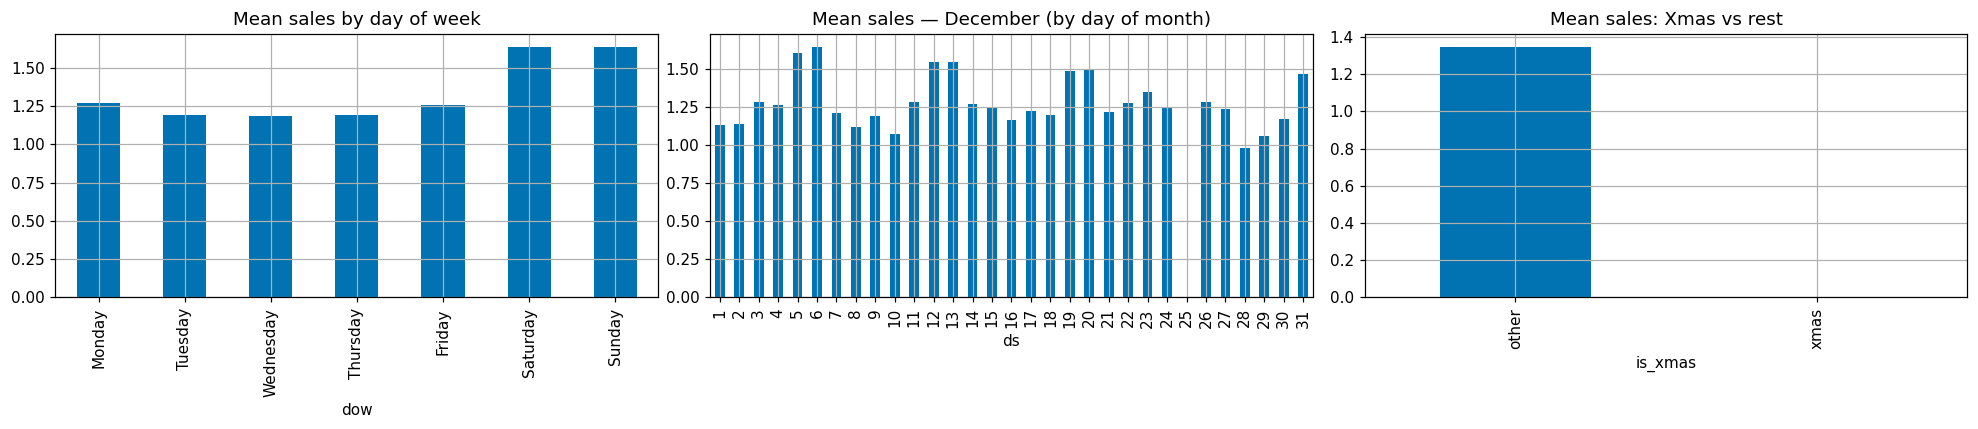

In [6]:
df_dow = df.assign(
    dow=df['ds'].dt.day_name(),
    month=df['ds'].dt.month,
    is_xmas=(df['ds'].dt.month == 12) & (df['ds'].dt.day == 25),
)
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
(df_dow.groupby('dow', observed=True)['y'].mean()
       .reindex(dow_order)
       .plot.bar(ax=axes[0], title='Mean sales by day of week'))
(df_dow[df_dow.month == 12].groupby(df_dow['ds'].dt.day, observed=True)['y'].mean()
       .plot.bar(ax=axes[1], title='Mean sales — December (by day of month)'))
(df_dow.groupby('is_xmas', observed=True)['y'].mean()
       .rename(index={False: 'other', True: 'xmas'})
       .plot.bar(ax=axes[2], title='Mean sales: Xmas vs rest'))
fig.tight_layout()

## Bottom-level (item × store) — the prediction target

Top-volume series are well-behaved with weekly seasonality; the long tail 
is intermittent.

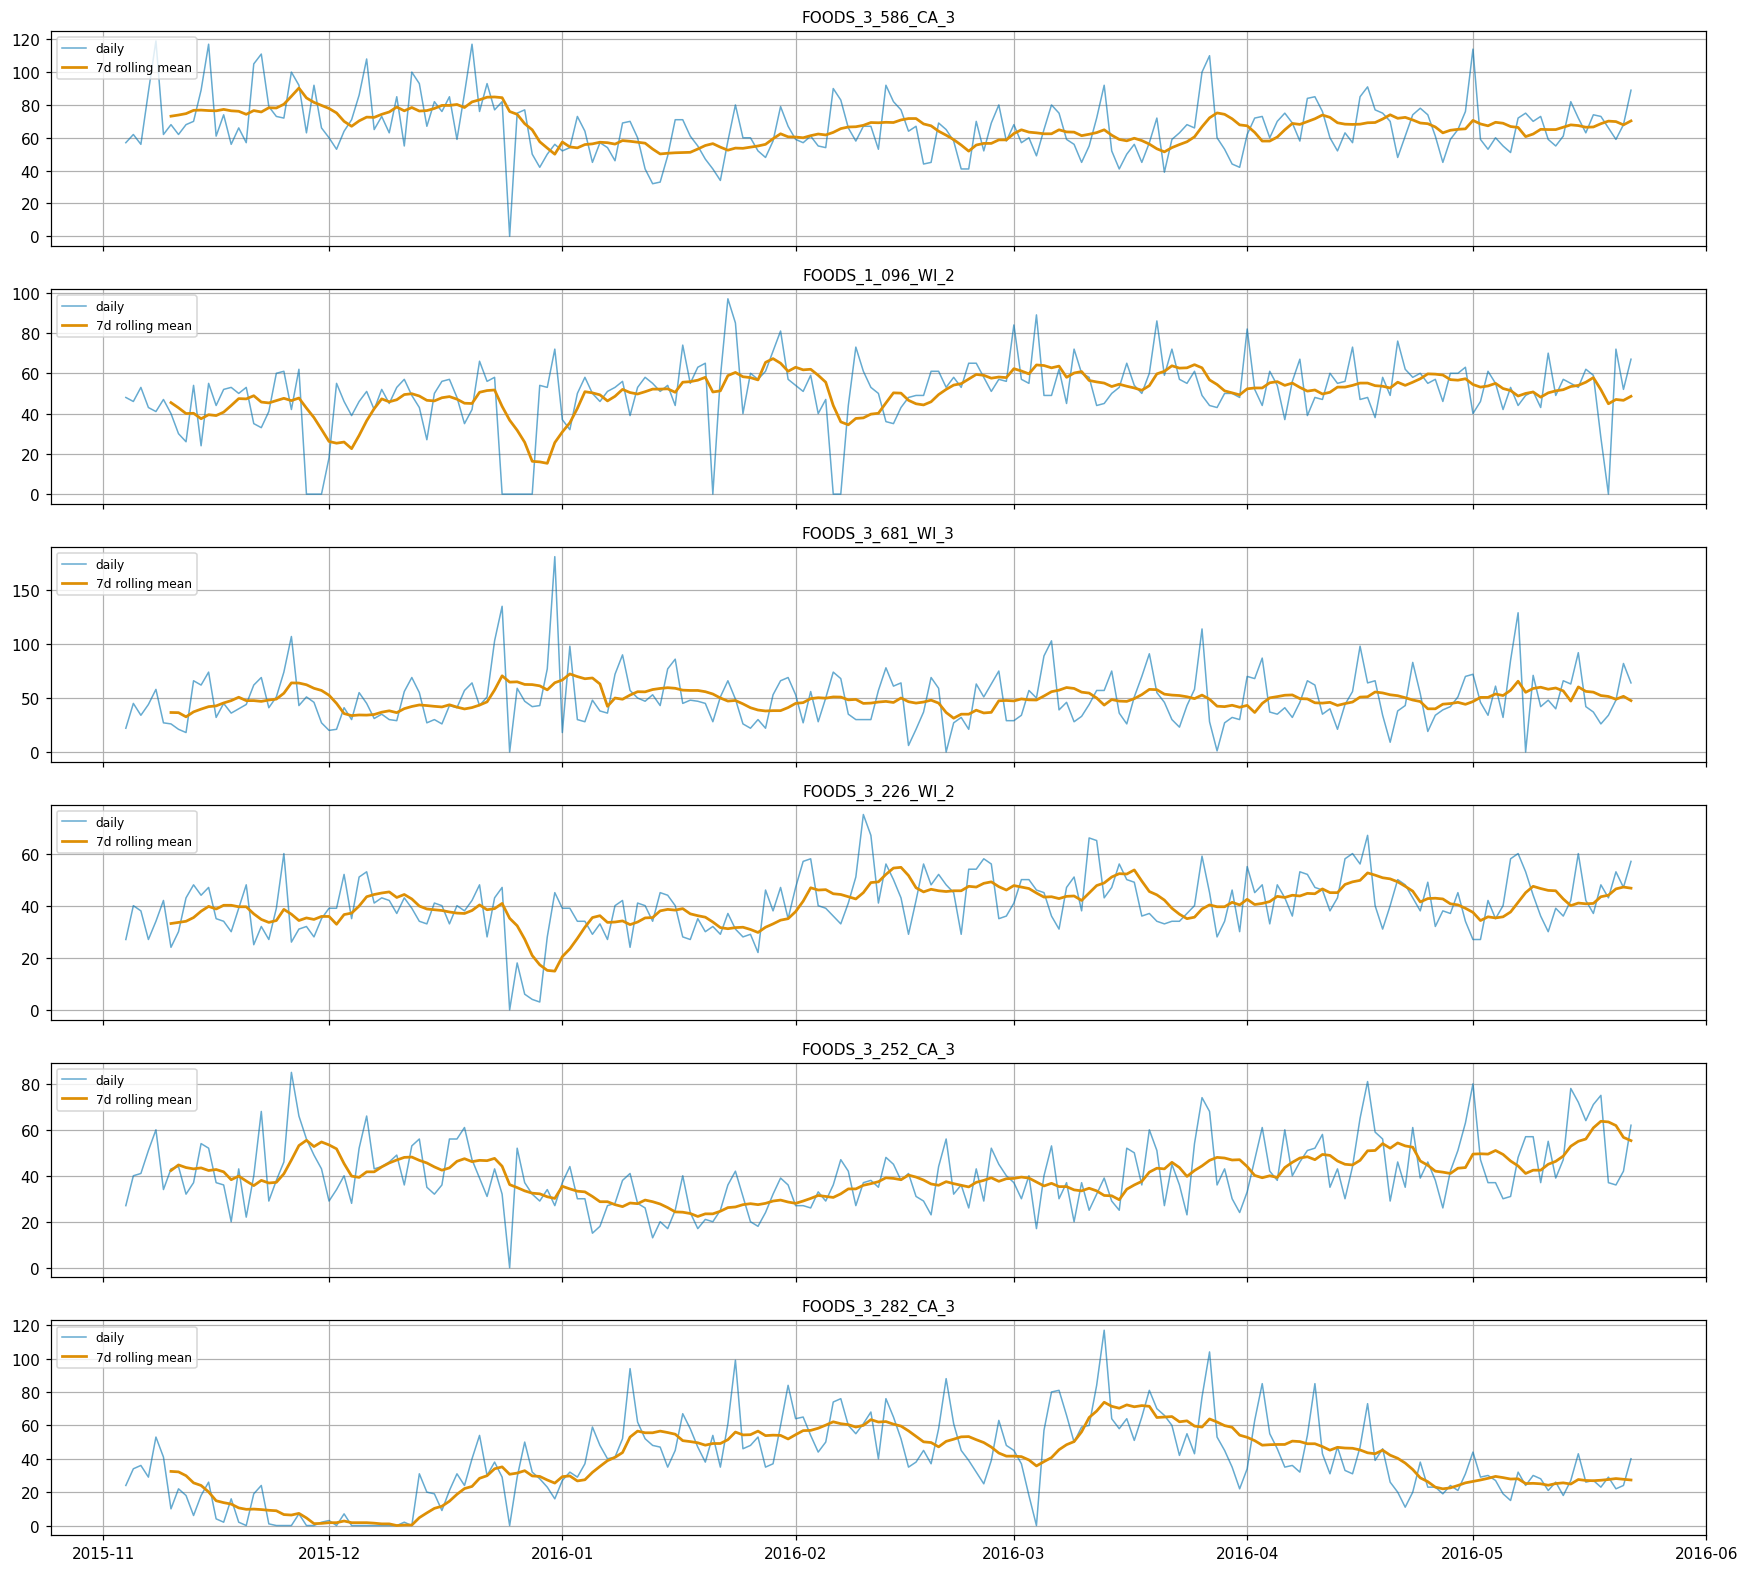

In [7]:
top_n = 6
top_ids = (df.groupby('unique_id', observed=True)['y'].sum()
             .sort_values(ascending=False).head(top_n).index.tolist())

fig, axes = plt.subplots(top_n, 1, figsize=(16, 2.4 * top_n), sharex=True)
for ax, uid in zip(axes, top_ids):
    sub = df[df['unique_id'] == uid].sort_values('ds')
    ax.plot(sub['ds'], sub['y'], lw=1.0, alpha=0.6, label='daily')
    ax.plot(sub['ds'], sub['y'].rolling(7).mean(), lw=1.8, label='7d rolling mean')
    ax.set_title(uid, fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()